# **Análisis Exploratorio de Datos (EDA) - Análisis Bidimensional**

En esta sección se estudia la relación entre las variables seleccionadas y la variable objetivo `default`, así como las relaciones entre variables independientes.

El propósito de este análisis es identificar variables con capacidad explicativa sobre el incumplimiento del préstamo y detectar posibles problemas de redundancia o multicolinealidad que puedan afectar el modelado posterior.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind, mannwhitneyu, chi2_contingency, pointbiserialr

sns.set(style="whitegrid")

DATA_PATH = Path(r"C:\Users\Daniel Rangel\Documents\MachineLearning\Data\accepted_2007_to_2018Q4.csv.gz")

df = pd.read_csv(DATA_PATH, low_memory=False)
df["default"] = df["loan_status"].apply(lambda x: 1 if x == "Charged Off" else 0)



In [2]:
num_vars = [
    "loan_amnt",
    "int_rate",
    "annual_inc",
    "dti",
    "fico_range_high",
    "revol_util",
    "open_acc",
    "total_acc"
]

cat_vars = [
    "emp_length",
    "purpose",
    "home_ownership",
    "addr_state"
]

## **Relación entre variables numéricas y la variable objetivo**

En esta subsección se analiza la relación entre las variables numéricas seleccionadas y la variable objetivo `default`.

Para ello, se utilizan visualizaciones comparativas por clase, diferencias de medias y medidas de asociación entre variables numéricas y la variable binaria de incumplimiento.

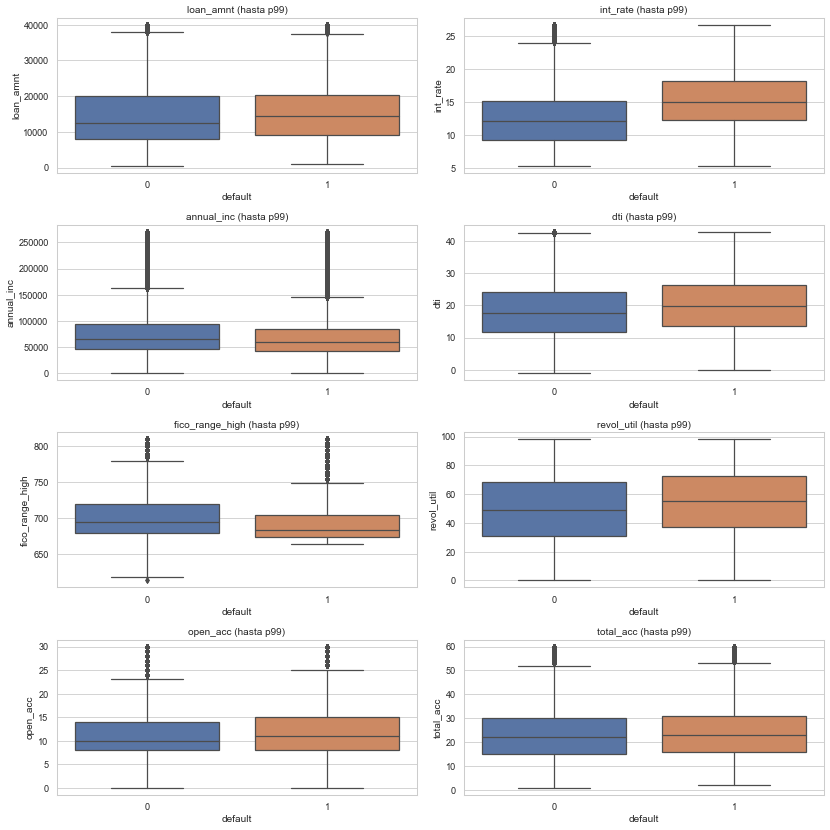

In [3]:
fig, axes = plt.subplots(4, 2, figsize=(14, 14), dpi=60)
axes = axes.flatten()

for ax, col in zip(axes, num_vars):
    temp = df[[col, "default"]].dropna().copy()

    upper = temp[col].quantile(0.99)
    temp = temp[temp[col] <= upper]

    sns.boxplot(data=temp, x="default", y=col, ax=ax)
    ax.set_title(f"{col} (hasta p99)")

plt.tight_layout()
plt.show()

Los diagramas de caja permiten comparar visualmente la distribución de cada variable numérica entre préstamos en default y no default, observando diferencias en medianas, dispersión y presencia de valores atípicos.

In [4]:
num_vs_target_results = []

for col in num_vars:
    temp = df[[col, "default"]].dropna()

    group_0 = temp[temp["default"] == 0][col]
    group_1 = temp[temp["default"] == 1][col]

    mean_0 = group_0.mean()
    mean_1 = group_1.mean()
    diff_means = mean_1 - mean_0

    # Mann-Whitney es más robusta aquí por no normalidad
    stat_mw, p_mw = mannwhitneyu(group_0, group_1, alternative="two-sided")

    # Correlación punto-biserial
    r_pb, p_pb = pointbiserialr(temp["default"], temp[col])

    num_vs_target_results.append({
        "variable": col,
        "mean_default_0": mean_0,
        "mean_default_1": mean_1,
        "diff_means": diff_means,
        "mannwhitney_pvalue": p_mw,
        "pointbiserial_r": r_pb,
        "pointbiserial_pvalue": p_pb
    })

num_vs_target_df = pd.DataFrame(num_vs_target_results).sort_values(
    by="pointbiserial_r", key=np.abs, ascending=False
)

num_vs_target_df

,variable,mean_default_0,mean_default_1,diff_means,mannwhitney_pvalue,pointbiserial_r,pointbiserial_pvalue
1,int_rate,12.739908,15.710714,2.970805,0.000000e+00,0.198918,0.000000e+00
4,fico_range_high,704.036036,691.850171,-12.185865,0.000000e+00,-0.119436,0.000000e+00
5,revol_util,49.741645,54.758433,5.016788,0.000000e+00,0.065684,0.000000e+00
3,dti,18.642504,20.171196,1.528692,0.000000e+00,0.034880,0.000000e+00
2,annual_inc,79015.876467,70400.743283,-8615.133185,0.000000e+00,-0.024734,8.421271e-303
0,loan_amnt,14977.082178,15565.055444,587.973266,0.000000e+00,0.020700,1.044396e-212
6,open_acc,11.573459,11.901269,0.327810,5.588754e-239,0.018803,7.405428e-176
7,total_acc,24.088836,24.709356,0.620520,1.796855e-140,0.016748,6.089099e-140


### **Diferencia de medias, prueba de Mann-Whitney y correlación punto-biserial**

La comparación entre clases muestra diferencias sistemáticas entre los préstamos en default (`default = 1`) y los no default (`default = 0`) en varias variables numéricas.

En particular, la variable `int_rate` presenta la asociación más fuerte con `default`, con una diferencia de medias cercana a 2.97 puntos porcentuales y una correlación punto-biserial positiva de 0.199. Esto sugiere que los préstamos en default tienden a estar asociados con tasas de interés más altas.

Por su parte, `fico_range_high` presenta una correlación negativa de -0.119 y una diferencia de medias de aproximadamente -12.19 puntos, lo cual indica que los casos de default tienden a concentrarse en solicitantes con menor puntaje crediticio.

Variables como `revol_util` y `dti` también muestran asociaciones positivas con `default`, lo que sugiere que un mayor uso del crédito revolvente y un mayor nivel de endeudamiento se relacionan con una mayor probabilidad de incumplimiento.

En contraste, `annual_inc` presenta una correlación negativa débil, indicando que los préstamos en default tienden, en promedio, a estar asociados con menores ingresos anuales.

La prueba de Mann-Whitney arroja valores p extremadamente pequeños en todas las variables analizadas, lo que indica que las diferencias entre clases son estadísticamente significativas. Sin embargo, la magnitud de la asociación no es igual en todos los casos: `int_rate` y `fico_range_high` destacan como las variables numéricas con mayor capacidad discriminante dentro del conjunto evaluado.

## **Relación entre variables categóricas y la variable objetivo**

En esta subsección se analiza la relación entre las variables categóricas seleccionadas y la variable objetivo `default`.

Para ello, se construyen tablas de contingencia que muestran la proporción de default por categoría, se generan visualizaciones comparativas y se aplica la prueba de chi-cuadrado para evaluar la independencia entre cada variable categórica y el incumplimiento del préstamo.

In [5]:
for col in cat_vars:
    print(f"\nVariable: {col}")
    
    ctab = pd.crosstab(df[col], df["default"], normalize="index") * 100
    ctab.columns = ["default_0_pct", "default_1_pct"]
    
    display(ctab.sort_values(by="default_1_pct", ascending=False))


Variable: emp_length


,default_0_pct,default_1_pct
emp_length,,
8 years,86.835520,13.164480
9 years,87.232193,12.767807
7 years,87.464265,12.535735
1 year,87.737445,12.262555
3 years,88.113060,11.886940
2 years,88.160666,11.839334
6 years,88.170870,11.829130
5 years,88.192386,11.807614
< 1 year,88.324526,11.675474



Variable: purpose


,default_0_pct,default_1_pct
purpose,,
small_business,81.449228,18.550772
renewable_energy,84.705882,15.294118
moving,85.626177,14.373823
educational,86.792453,13.207547
debt_consolidation,87.086864,12.913136
medical,87.678260,12.321740
wedding,88.152866,11.847134
other,88.249426,11.750574
house,88.773345,11.226655



Variable: home_ownership


,default_0_pct,default_1_pct
home_ownership,,
OTHER,85.164835,14.835165
RENT,86.135883,13.864117
NONE,87.037037,12.962963
OWN,88.198706,11.801294
MORTGAGE,89.695353,10.304647
ANY,94.377510,5.622490



Variable: addr_state


,default_0_pct,default_1_pct
addr_state,,
AL,85.610614,14.389386
AR,85.826403,14.173597
LA,86.051477,13.948523
OK,86.066406,13.933594
NV,86.394954,13.605046
MS,86.407152,13.592848
NM,86.876356,13.123644
NY,87.009427,12.990573
SD,87.030117,12.969883


### Interpretación de las tablas de contingencia

Las tablas de contingencia muestran diferencias claras en la tasa de default entre categorías de las variables analizadas, lo que sugiere que estas variables podrían aportar información relevante para el modelado.

En la variable `emp_length`, se observa que las mayores tasas de default corresponden a categorías intermedias de experiencia laboral, particularmente `8 years`, `9 years` y `7 years`, mientras que la categoría `10+ years` presenta una tasa de impago relativamente menor. En general, las diferencias no son extremadamente amplias, pero sí evidencian cierta variabilidad entre niveles de experiencia.

En `purpose` se observan contrastes más marcados. Las categorías `small_business`, `renewable_energy` y `moving` presentan las tasas de default más altas, destacándose especialmente `small_business` con una tasa cercana al 18.6%. Por el contrario, categorías como `car` y `credit_card` presentan tasas de impago menores, lo que sugiere que el propósito del préstamo podría constituir un predictor relevante del incumplimiento.

En cuanto a `home_ownership`, la categoría `RENT` presenta una tasa de default superior a `OWN` y `MORTGAGE`, mientras que `MORTGAGE` muestra una tasa de impago relativamente más baja. Aunque categorías como `ANY`, `NONE` y `OTHER` presentan comportamientos particulares, su interpretación debe realizarse con cautela debido a su baja frecuencia.

Finalmente, en `addr_state` también se observan diferencias notables entre estados. Algunos estados como `AL`, `AR`, `LA` y `OK` presentan tasas de default relativamente más altas, mientras que otros como `ME`, `IA`, `ID` y `VT` muestran tasas menores. Esto sugiere que la ubicación geográfica podría capturar diferencias regionales relevantes en el comportamiento de pago.

En conjunto, estas diferencias respaldan la idea de que las variables categóricas seleccionadas contienen señales útiles para distinguir entre préstamos en default y no default.

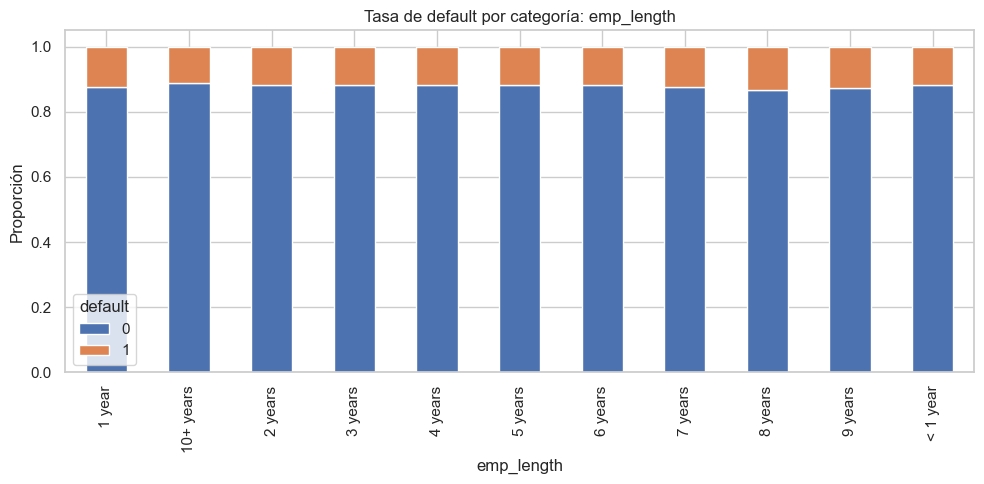

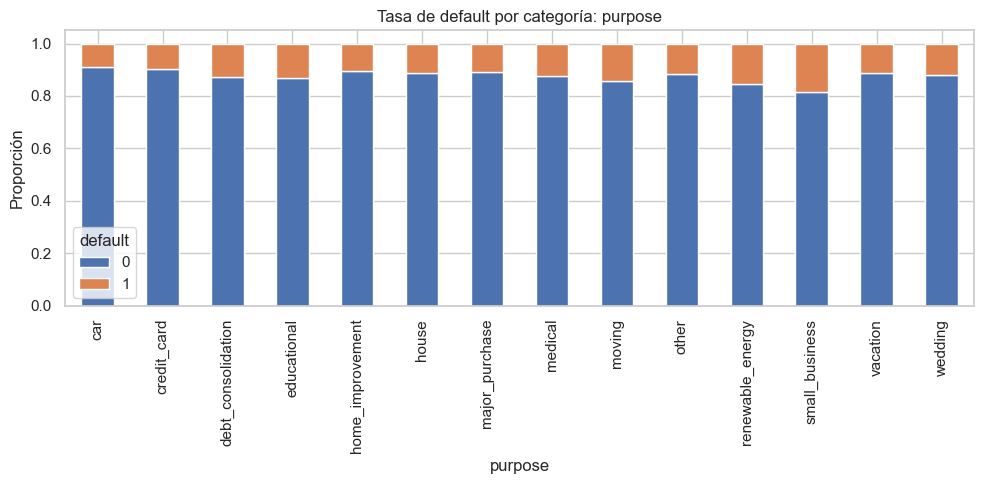

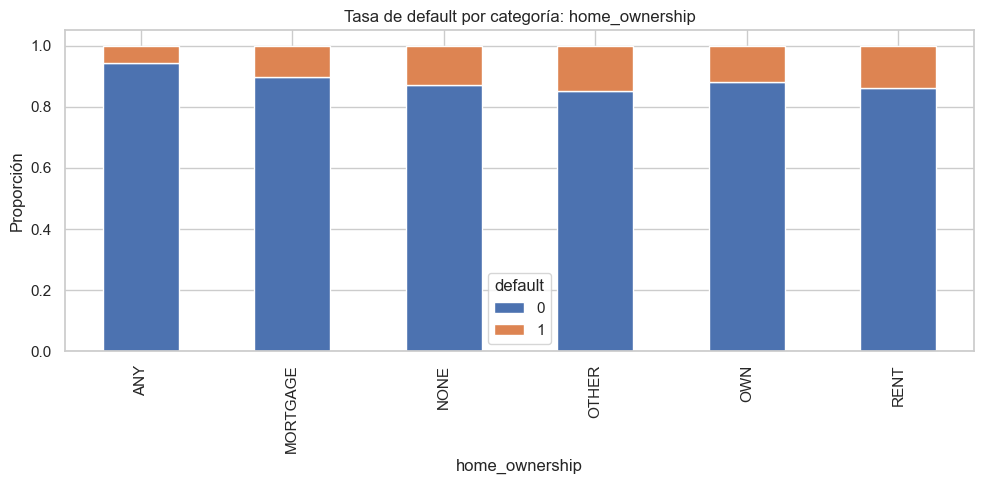

In [6]:
main_cat_vars = ["emp_length", "purpose", "home_ownership"]

for col in main_cat_vars:
    ctab = pd.crosstab(df[col], df["default"], normalize="index")
    ctab.plot(kind="bar", stacked=True, figsize=(10, 5))
    plt.title(f"Tasa de default por categoría: {col}")
    plt.ylabel("Proporción")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

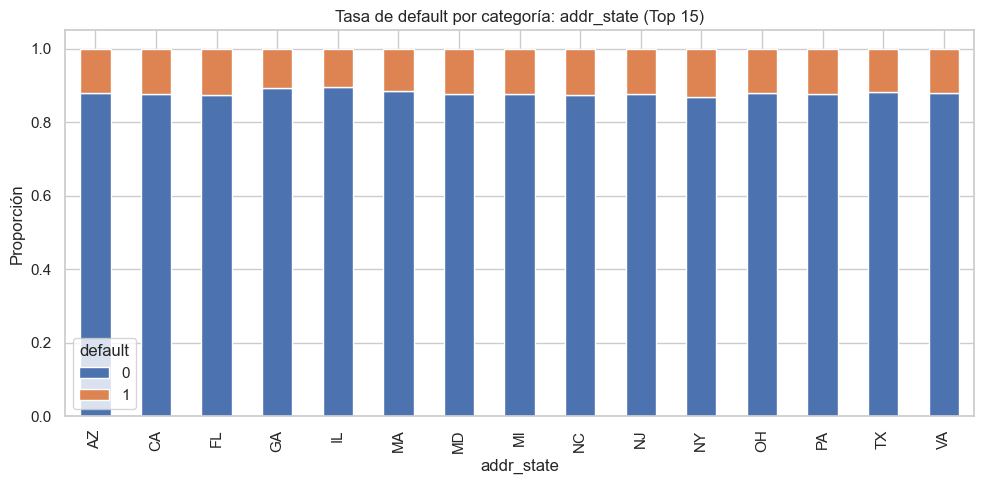

In [7]:
top_states = df["addr_state"].value_counts().head(15).index

ctab_states = pd.crosstab(
    df[df["addr_state"].isin(top_states)]["addr_state"],
    df[df["addr_state"].isin(top_states)]["default"],
    normalize="index"
)

ctab_states.plot(kind="bar", stacked=True, figsize=(10, 5))
plt.title("Tasa de default por categoría: addr_state (Top 15)")
plt.ylabel("Proporción")
plt.xlabel("addr_state")
plt.tight_layout()
plt.show()

### **Interpretación de los gráficos de barras apiladas**

Los gráficos de barras apiladas confirman visualmente el desbalance general de la variable objetivo, con un claro predominio de la clase `0` sobre la clase `1` en todas las variables analizadas. Sin embargo, a pesar de este sesgo global, sí se observan diferencias en la proporción relativa de default entre categorías.

En `emp_length`, las diferencias entre categorías son relativamente moderadas, aunque algunas categorías intermedias muestran una proporción de default ligeramente superior. Esto sugiere que la experiencia laboral podría tener cierta relación con el incumplimiento, aunque su efecto visual parece menos marcado que en otras variables.

En `purpose`, el efecto es más evidente. Categorías como `small_business`, `renewable_energy` y `moving` presentan una proporción de default mayor que categorías como `car` o `credit_card`, lo que sugiere que el propósito del préstamo podría ser un predictor relevante del riesgo de incumplimiento.

En `home_ownership`, también se observan diferencias claras. Categorías como `RENT` y `OTHER` muestran una mayor proporción de default en comparación con `OWN` y `MORTGAGE`, mientras que esta última presenta un comportamiento relativamente más estable.

En `addr_state`, aunque las diferencias son más sutiles visualmente, se aprecia que algunos estados presentan una proporción de default mayor que otros, lo cual sugiere la existencia de variaciones regionales en el comportamiento de pago.

En conjunto, las visualizaciones refuerzan la evidencia de que las variables categóricas seleccionadas presentan asociaciones con la variable objetivo y podrían aportar información útil en el modelado posterior.

### **Prueba de chi-cuadrado para variables categóricas**

Con el fin de evaluar formalmente la relación entre cada variable categórica y la variable objetivo `default`, se aplica la prueba de chi-cuadrado de independencia.

Esta prueba permite determinar si la distribución de default depende de la categoría analizada. Valores pequeños de *p-value* indican que existe evidencia estadística de asociación entre la variable categórica y la variable objetivo.

In [8]:
from scipy.stats import chi2_contingency

chi2_results = []

for col in cat_vars:
    temp = df[[col, "default"]].dropna()
    contingency = pd.crosstab(temp[col], temp["default"])

    chi2, p, dof, expected = chi2_contingency(contingency)

    chi2_results.append({
        "variable": col,
        "chi2": chi2,
        "p_value": p,
        "degrees_freedom": dof
    })

chi2_df = pd.DataFrame(chi2_results).sort_values(by="p_value")
chi2_df

,variable,chi2,p_value,degrees_freedom
1,purpose,5506.641353,0.000000e+00,13
2,home_ownership,6040.699202,0.000000e+00,5
3,addr_state,3226.072554,0.000000e+00,50
0,emp_length,657.343314,8.950601e-135,10


### **Interpretación de la prueba de chi-cuadrado**

Los resultados de la prueba de chi-cuadrado muestran que todas las variables categóricas analizadas presentan asociación estadísticamente significativa con la variable objetivo `default`, dado que en todos los casos los *p-values* son extremadamente pequeños.

Entre las variables evaluadas, `home_ownership` y `purpose` presentan los valores más altos del estadístico chi-cuadrado, lo que sugiere una asociación más marcada con el incumplimiento del préstamo dentro del conjunto analizado.

La variable `addr_state` también presenta evidencia significativa de asociación con `default`, lo cual respalda la existencia de diferencias regionales en el comportamiento de pago. Por su parte, `emp_length`, aunque presenta un estadístico chi-cuadrado menor en comparación con las demás, también muestra una relación estadísticamente significativa con la variable objetivo.

En conjunto, estos resultados confirman que las variables categóricas seleccionadas no son independientes de `default` y, por tanto, pueden aportar información relevante para el modelado predictivo.

En consecuencia, tanto el análisis descriptivo como la prueba de chi-cuadrado sugieren que `purpose`, `home_ownership`, `addr_state` y `emp_length` contienen señales útiles para distinguir entre préstamos en default y no default.

## **Relación entre variables independientes**

Además de analizar la relación entre las variables y la variable objetivo, es importante estudiar la asociación entre variables independientes, con el fin de identificar posibles problemas de multicolinealidad o redundancia que puedan afectar el modelado posterior.

In [9]:
corr_matrix = df[num_vars].corr()
corr_matrix

,loan_amnt,int_rate,annual_inc,dti,fico_range_high,revol_util,open_acc,total_acc
loan_amnt,1.000000,0.098082,0.197246,0.043542,0.110584,0.099078,0.182229,0.199570
int_rate,0.098082,1.000000,-0.050583,0.124491,-0.415991,0.262670,-0.010472,-0.040951
annual_inc,0.197246,-0.050583,1.000000,-0.082619,0.037008,0.028207,0.094377,0.115271
dti,0.043542,0.124491,-0.082619,1.000000,-0.027931,0.115225,0.186124,0.147335
fico_range_high,0.110584,-0.415991,0.037008,-0.027931,1.000000,-0.476999,0.018405,0.016192
revol_util,0.099078,0.262670,0.028207,0.115225,-0.476999,1.000000,-0.134632,-0.093147
open_acc,0.182229,-0.010472,0.094377,0.186124,0.018405,-0.134632,1.000000,0.717911
total_acc,0.199570,-0.040951,0.115271,0.147335,0.016192,-0.093147,0.717911,1.000000


### **Interpretación de la matriz de correlación**

La matriz de correlación muestra que, en general, las variables numéricas seleccionadas no presentan niveles extremos de correlación lineal, lo que sugiere una ausencia de multicolinealidad severa dentro de este subconjunto.

Sin embargo, se identifican algunos pares con asociaciones relativamente más altas:

- `open_acc` y `total_acc` presentan una correlación positiva de aproximadamente **0.718**, lo cual supera el umbral de 0.7 y sugiere una posible redundancia parcial, dado que ambas variables reflejan aspectos relacionados con el número de cuentas de crédito.
- `fico_range_high` y `revol_util` muestran una correlación negativa moderada de aproximadamente **-0.477**, lo que indica que mayores niveles de utilización del crédito tienden a asociarse con menores puntajes crediticios.
- `int_rate` y `fico_range_high` presentan una correlación negativa moderada de aproximadamente **-0.416**, consistente con la lógica financiera según la cual perfiles crediticios más sólidos suelen recibir tasas de interés menores.

Fuera de estos casos, la mayoría de las correlaciones se mantienen en magnitudes bajas o moderadas, lo cual sugiere que las variables capturan dimensiones diferentes del perfil financiero del solicitante.

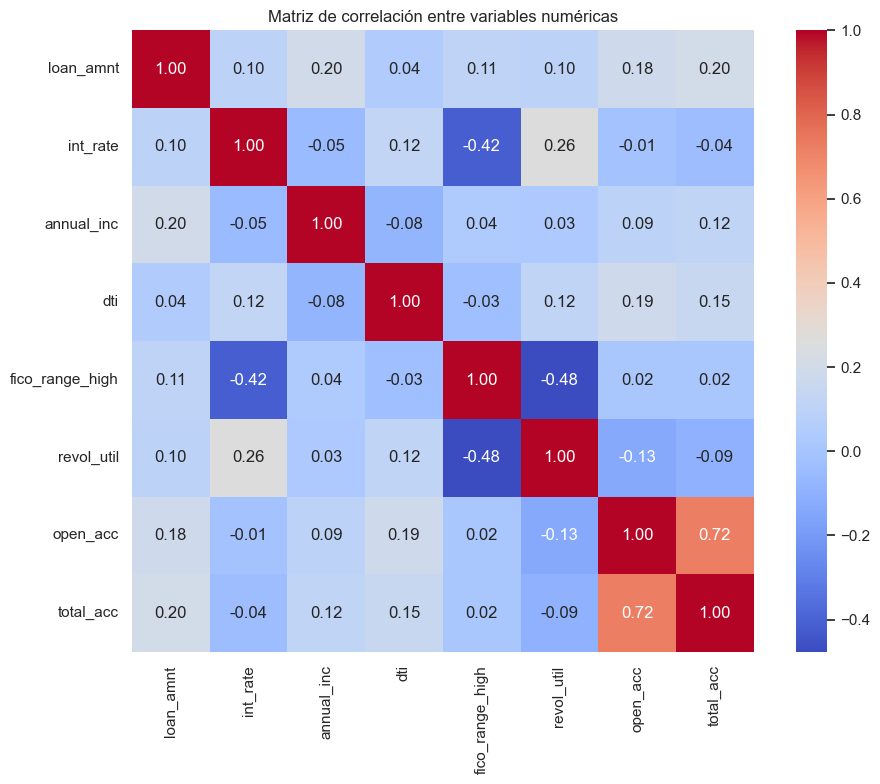

In [10]:
plt.figure(figsize=(10, 8), dpi=100)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Matriz de correlación entre variables numéricas")
plt.tight_layout()
plt.show()

#### **Pares de variables con mayor correlación**

El análisis de pares confirma que la correlación más alta dentro del conjunto seleccionado corresponde a `open_acc` y `total_acc`, con un valor de aproximadamente **0.718**, lo cual supera el umbral de 0.7 y sugiere una posible redundancia parcial entre ambas variables. Esto es consistente con el hecho de que ambas describen dimensiones relacionadas con la cantidad de cuentas de crédito del solicitante.

También se observan correlaciones negativas moderadas entre `fico_range_high` y `revol_util` (**-0.477**), así como entre `int_rate` y `fico_range_high` (**-0.416**). Estas relaciones son coherentes con la lógica del riesgo crediticio: mayores niveles de utilización del crédito y mayores tasas de interés tienden a asociarse con perfiles crediticios menos favorables.

Fuera de estos casos, las correlaciones restantes presentan magnitudes bajas o moderadas, lo cual indica que la mayoría de las variables seleccionadas aporta información complementaria en lugar de altamente redundante.

En consecuencia, no se observa un problema severo de multicolinealidad en el subconjunto analizado, aunque el par `open_acc`–`total_acc` deberá considerarse con atención en la etapa de modelado.

## **Asociación entre variables categóricas**

Además de la relación entre las variables categóricas y la variable objetivo, se analiza la asociación entre pares de variables categóricas con el fin de detectar posibles redundancias o dependencias entre ellas.

In [11]:
from scipy.stats import chi2_contingency

cat_assoc_results = []

for i in range(len(cat_vars)):
    for j in range(i + 1, len(cat_vars)):
        var1 = cat_vars[i]
        var2 = cat_vars[j]

        temp = df[[var1, var2]].dropna()
        contingency = pd.crosstab(temp[var1], temp[var2])

        chi2, p, dof, expected = chi2_contingency(contingency)

        cat_assoc_results.append({
            "var1": var1,
            "var2": var2,
            "chi2": chi2,
            "p_value": p,
            "degrees_freedom": dof
        })

cat_assoc_df = pd.DataFrame(cat_assoc_results).sort_values(by="p_value")
cat_assoc_df

,var1,var2,chi2,p_value,degrees_freedom
0,emp_length,purpose,11355.661959,0.0,130
1,emp_length,home_ownership,86921.991876,0.0,50
2,emp_length,addr_state,8684.767641,0.0,500
3,purpose,home_ownership,84785.168976,0.0,65
4,purpose,addr_state,12667.000251,0.0,650
5,home_ownership,addr_state,144596.073997,0.0,250


### **Interpretación de la asociación entre variables categóricas**

Los resultados muestran que todos los pares de variables categóricas analizados presentan asociación estadísticamente significativa, dado que en todos los casos el *p-value* es prácticamente cero.

Esto indica que las variables categóricas seleccionadas no son independientes entre sí y que existe cierto grado de relación estructural entre distintas características del solicitante y del préstamo.

En particular, las asociaciones más fuertes se observan entre `home_ownership` y `addr_state`, así como entre `emp_length` y `home_ownership`, y entre `purpose` y `home_ownership`. Estos resultados sugieren que algunas de estas variables podrían capturar información parcialmente relacionada, por ejemplo, diferencias regionales en la tenencia de vivienda o patrones de empleo y propósito del préstamo según el perfil del solicitante.

No obstante, el hecho de que exista asociación estadística no implica necesariamente una redundancia completa. En este contexto, estos resultados deben interpretarse como evidencia de dependencia entre variables categóricas, lo cual será útil para considerar posibles solapamientos de información en la etapa de modelado.

En conjunto, este análisis sugiere que las variables categóricas seleccionadas contienen relaciones entre sí, aunque aún pueden aportar información complementaria para la predicción del default.

## **Visualizaciones avanzadas sugeridas**

Dado el tamaño del dataset, las visualizaciones avanzadas se realizarán sobre una muestra representativa únicamente con fines exploratorios y de interpretación gráfica.

Esto no afecta el modelado posterior, que seguirá realizándose sobre el conjunto completo de datos.

c:\Users\Daniel Rangel\miniconda3\envs\ml_rangel\lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


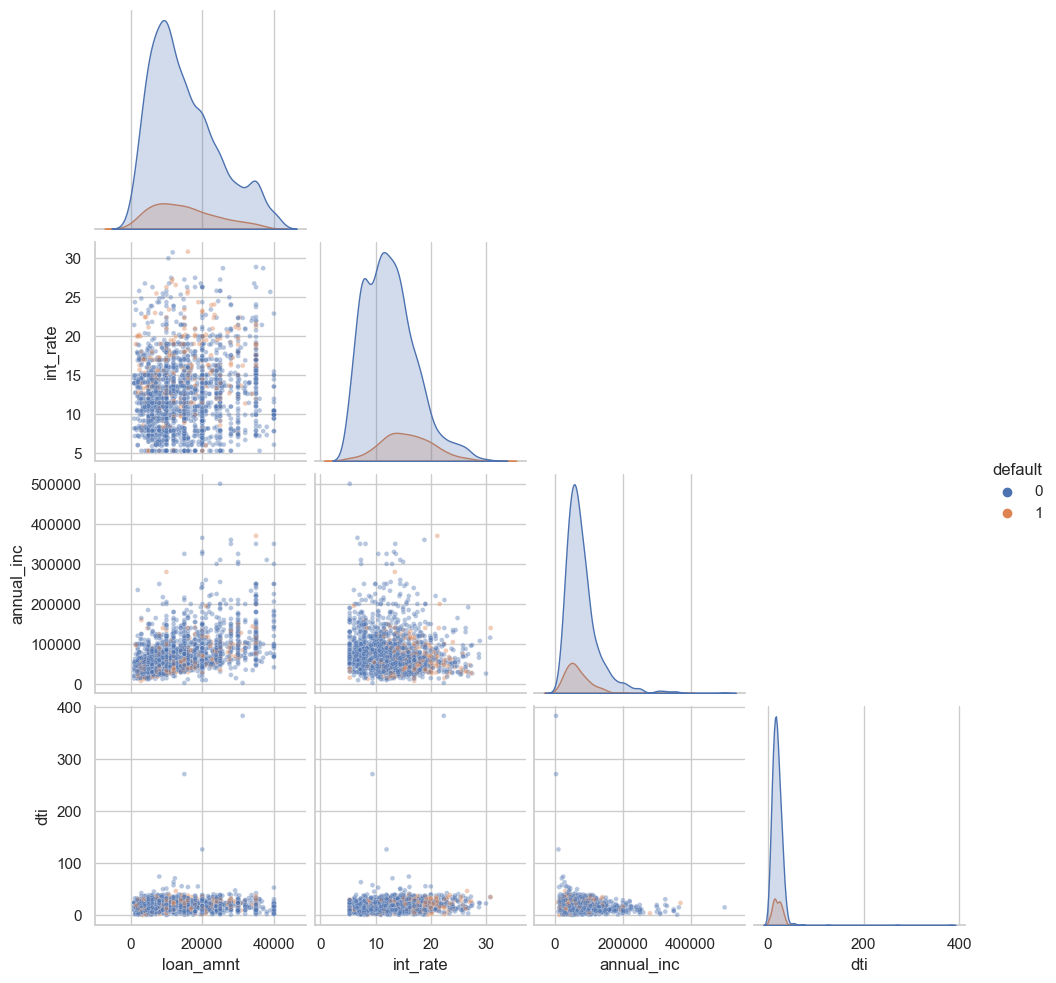

In [12]:
sample_pairplot = df[num_vars + ["default"]].dropna().sample(2000, random_state=42)

sns.pairplot(
    sample_pairplot,
    vars=["loan_amnt", "int_rate", "annual_inc", "dti"],
    hue="default",
    corner=True,
    plot_kws={"alpha": 0.4, "s": 12}
)
plt.show()

### **Interpretación del pairplot**

El pairplot permite visualizar de manera conjunta la distribución de varias variables numéricas y su relación con la variable objetivo `default`.

En la diagonal se observa la distribución individual de cada variable, mientras que fuera de la diagonal se representan relaciones bivariadas entre pares de variables.

En general, se aprecia una superposición importante entre las clases `default = 0` y `default = 1`, lo que sugiere que no existe una separación perfectamente definida entre ambas clases a partir de estas variables de forma individual. No obstante, sí se observan algunas diferencias en variables como `int_rate`, donde los casos de default tienden a concentrarse en valores relativamente más altos.

Este resultado es consistente con problemas reales de clasificación crediticia, en los que la separación entre clases suele depender de la combinación de varias variables más que de una única característica aislada.